# IMDB Top 1000 Movies & TV Shows — Data Analysis
**Name:** Amelia Eric-Markovic  
**Student ID:** 100818139

**Dataset:** IMDB Dataset of Top 1000 Movies and TV Shows (Kaggle)

**Notebook file:** `IMDB.ipynb`

**Notes:** This notebook expects a CSV file named `imdb_top_1000.csv` in the same folder as the notebook. Download the CSV from the Kaggle dataset page you provided and place it alongside this notebook before running all cells.

---



## Introduction

This project explores a dataset titled “IMDB Dataset of Top 1000 Movies and TV Shows,” originally sourced from Kaggle. I chose this dataset because it brings together a wide mix of movie-related information such as genres, cast lists, directors, ratings, financial performance, and more, which makes it a great starting point for asking questions about what really drives a film’s success. Since the dataset includes both creative elements (like genre and cast) and performance metrics (like gross revenue, ratings, and metascore), it naturally raises the question: **What makes a movie a blockbuster?** That idea became the central theme of the project.

Once I began exploring the data, several interesting patterns and questions emerged. For example, certain genres seem to appear more often among high-grossing films, which made me wonder which specific genre combinations tend to outperform others, or if its better to obtain the individual genres and combine the ones that gross the highest to make something new that would still preform well with audiences. I also noticed how frequently the same big-name actors and directors show up in successful movies, so I wanted to test which two leading actors that have not been in a movie together could still gross a highly profitable film. Other factors, such as runtime, IMDB ratings, and metascore, also seemed potentially relevant, so the project investigates how each of these might relate to financial outcomes.

Because the dataset includes categorical, numerical, and text features, it allowed for a broad mix of analysis techniques. I cleaned and prepared the data, expanded certain columns (like splitting multi-genre labels), and used grouped summaries and visualizations to uncover trends. Much of the analysis looks at averages, correlations, and comparisons across categories, for example, which genres bring in the most revenue on average, or whether higher metascores actually correspond to higher grosses.

Overall, the goal of this project is to combine simple statistical tools with thoughtful exploration to better understand what ingredients tend to show up in the biggest hits. While the dataset can’t definitively *“predict”* the next blockbuster, it does highlight consistent patterns that help reveal what kinds of movies historically perform the best.


In [ ]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Settings for nicer plots in the notebook
%matplotlib inline
# Show all rows and columns
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)            # Increase console width
pd.set_option('display.max_colwidth', None)    # Show full content in each cell
plt.rcParams['figure.figsize'] = (8,5)

# Load CSV (expects local file named 'imdb_top_1000.csv')
import os
csv_filename = 'imdb_top_1000.csv'
if not os.path.exists(csv_filename):
    raise FileNotFoundError(f"'{csv_filename}' not found. Please download the CSV from Kaggle and place it in the same folder as this notebook. Original Kaggle page: https://www.kaggle.com/datasets/harshitshankhdhar/imdb-dataset-of-top-1000-movies-and-tv-shows")
    
df = pd.read_csv(csv_filename)

# === Cleaning / Preparation ===

# Remove commas from Gross and convert to numeric
df["Gross"] = df["Gross"].replace(",", "", regex=True)
df["Gross"] = pd.to_numeric(df["Gross"], errors="coerce")

# Convert Meta_score to numeric
df["Meta_score"] = pd.to_numeric(df["Meta_score"], errors="coerce")

# Convert Runtime like "142 min" to 142
df["Runtime"] = df["Runtime"].replace(" min", "", regex=True)
df["Runtime"] = pd.to_numeric(df["Runtime"], errors="coerce")

# Convert IMDB_Rating to numeric (should already be numeric but just in case)
df["IMDB_Rating"] = pd.to_numeric(df["IMDB_Rating"], errors="coerce")

# Convert Released_Year to numeric
df["Released_Year"] = pd.to_numeric(df["Released_Year"], errors="coerce")
# Convert to integer (drop decimals)
df["Released_Year"] = df["Released_Year"].astype("Int64") 

# No_of_votes to numeric
df["No_of_Votes"] = pd.to_numeric(df["No_of_Votes"], errors="coerce")

# Quick peek at our newly revised dataset!
print('CSV loaded. Shape:', df.shape)
df.dtypes
df.head()



CSV loaded. Shape: (1000, 16)


,Poster_Link,Series_Title,Released_Year,Certificate,Runtime,Genre,IMDB_Rating,Overview,Meta_score,Director,Star1,Star2,Star3,Star4,No_of_Votes,Gross
0,"https://m.media-amazon.com/images/M/MV5BMDFkYTc0MGEtZmNhMC00ZDIzLWFmNTEtODM1ZmRlYWMwMWFmXkEyXkFqcGdeQXVyMTMxODk2OTU@._V1_UX67_CR0,0,67,98_AL_.jpg",The Shawshank Redemption,1994,A,142,Drama,9.3,"Two imprisoned men bond over a number of years, finding solace and eventual redemption through acts of common decency.",80.0,Frank Darabont,Tim Robbins,Morgan Freeman,Bob Gunton,William Sadler,2343110,28341469.0
1,"https://m.media-amazon.com/images/M/MV5BM2MyNjYxNmUtYTAwNi00MTYxLWJmNWYtYzZlODY3ZTk3OTFlXkEyXkFqcGdeQXVyNzkwMjQ5NzM@._V1_UY98_CR1,0,67,98_AL_.jpg",The Godfather,1972,A,175,"Crime, Drama",9.2,An organized crime dynasty's aging patriarch transfers control of his clandestine empire to his reluctant son.,100.0,Francis Ford Coppola,Marlon Brando,Al Pacino,James Caan,Diane Keaton,1620367,134966411.0
2,"https://m.media-amazon.com/images/M/MV5BMTMxNTMwODM0NF5BMl5BanBnXkFtZTcwODAyMTk2Mw@@._V1_UX67_CR0,0,67,98_AL_.jpg",The Dark Knight,2008,UA,152,"Action, Crime, Drama",9.0,"When the menace known as the Joker wreaks havoc and chaos on the people of Gotham, Batman must accept one of the greatest psychological and physical tests of his ability to fight injustice.",84.0,Christopher Nolan,Christian Bale,Heath Ledger,Aaron Eckhart,Michael Caine,2303232,534858444.0
3,"https://m.media-amazon.com/images/M/MV5BMWMwMGQzZTItY2JlNC00OWZiLWIyMDctNDk2ZDQ2YjRjMWQ0XkEyXkFqcGdeQXVyNzkwMjQ5NzM@._V1_UY98_CR1,0,67,98_AL_.jpg",The Godfather: Part II,1974,A,202,"Crime, Drama",9.0,"The early life and career of Vito Corleone in 1920s New York City is portrayed, while his son, Michael, expands and tightens his grip on the family crime syndicate.",90.0,Francis Ford Coppola,Al Pacino,Robert De Niro,Robert Duvall,Diane Keaton,1129952,57300000.0
4,"https://m.media-amazon.com/images/M/MV5BMWU4N2FjNzYtNTVkNC00NzQ0LTg0MjAtYTJlMjFhNGUxZDFmXkEyXkFqcGdeQXVyNjc1NTYyMjg@._V1_UX67_CR0,0,67,98_AL_.jpg",12 Angry Men,1957,U,96,"Crime, Drama",9.0,A jury holdout attempts to prevent a miscarriage of justice by forcing his colleagues to reconsider the evidence.,96.0,Sidney Lumet,Henry Fonda,Lee J. Cobb,Martin Balsam,John Fiedler,689845,4360000.0


In [ ]:
# ===============================
# EXPLORATORY DATAFRAME ANALYSIS
# ===============================

# Basic info
print('=== DataFrame info ===')
# Checks data types
df.info()

# Column names and sample
print('\nColumns:', df.columns.tolist())

# Missing values (counts and percent)
missing_counts = df.isna().sum()
missing_perc = (missing_counts / len(df) * 100).round(2)
missing_df = pd.DataFrame({'missing_count': missing_counts, 'missing_percent': missing_perc})
missing_df.sort_values('missing_count', ascending=False)

# Basic distribution statistics for numeric columns (mean, median, std, min, max)
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print('Numeric columns detected:', numeric_cols)
df[numeric_cols].describe().transpose()[['count','mean','50%','std','min','max']].rename(columns={'50%':'median'})


=== DataFrame info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Poster_Link    1000 non-null   object 
 1   Series_Title   1000 non-null   object 
 2   Released_Year  999 non-null    Int64  
 3   Certificate    899 non-null    object 
 4   Runtime        1000 non-null   int64  
 5   Genre          1000 non-null   object 
 6   IMDB_Rating    1000 non-null   float64
 7   Overview       1000 non-null   object 
 8   Meta_score     843 non-null    float64
 9   Director       1000 non-null   object 
 10  Star1          1000 non-null   object 
 11  Star2          1000 non-null   object 
 12  Star3          1000 non-null   object 
 13  Star4          1000 non-null   object 
 14  No_of_Votes    1000 non-null   int64  
 15  Gross          831 non-null    float64
dtypes: Int64(1), float64(3), int64(2), object(10)
memory usage: 126.1+ KB

Col

,count,mean,median,std,min,max
Released_Year,999.0,1991.217217,1999.0,23.297025,1920.0,2020.0
Runtime,1000.0,122.891,119.0,28.093671,45.0,321.0
IMDB_Rating,1000.0,7.9493,7.9,0.275491,7.6,9.3
Meta_score,843.0,77.97153,79.0,12.376099,28.0,100.0
No_of_Votes,1000.0,273692.911,138548.5,327372.703934,25088.0,2343110.0
Gross,831.0,68034750.873646,23530892.0,109750043.192185,1305.0,936662225.0


In [ ]:
# =================================================================
# GENRE ANALYSIS — TWO METHODS (COMBINED AND SEPERATED)
# =================================================================

# Part 1 — Genre Combinations (raw IMDB labels like "Action, Adventure, Sci-Fi")
genre_combo = df.groupby("Genre")["Gross"].mean().sort_values(ascending=False).head(5)
genre_combo_df = genre_combo.reset_index()
genre_combo_df.columns = ["Genre Combination", "Average Gross"]
genre_combo_df["Average Gross"] = genre_combo_df["Average Gross"].map('${:,.0f}'.format)

print("\n=== TOP 5 EARNING GENRE COMBINATIONS (RAW IMDB LABELS) ===")
display(genre_combo_df)

# Part 2 — Individual Genres (split multi-genre movies)
df_gen = df.copy()
df_gen["Genre"] = df_gen["Genre"].str.split(", ")
df_exp = df_gen.explode("Genre")

# Aggregate by individual genres
genre_stats = df_exp.groupby("Genre").agg(
    total_movies=("Gross", "count"),
    total_gross=("Gross", "sum"),
    average_gross=("Gross", "mean")
).sort_values(by="average_gross", ascending=False).head(5)
# Save for blueprint (Final Analysis)
top_genre = genre_stats.index[0]

# Format dollar values and round averages
genre_stats["total_gross"] = genre_stats["total_gross"].map('${:,.0f}'.format)
genre_stats["average_gross"] = genre_stats["average_gross"].map('${:,.0f}'.format)
genre_stats.reset_index(inplace=True)
genre_stats.columns = ["Individual Genre", "Total Movies", "Total Gross", "Average Gross"]

print("\n=== TOP 5 EARNING INDIVIDUAL GENRES (AFTER SPLITTING) ===")
display(genre_stats)



=== TOP 5 EARNING GENRE COMBINATIONS (RAW IMDB LABELS) ===


,Genre Combination,Average Gross
0,"Family, Sci-Fi","$435,110,554"
1,"Action, Adventure, Fantasy","$352,723,505"
2,"Action, Adventure, Family","$301,959,197"
3,"Action, Adventure, Sci-Fi","$280,888,546"
4,"Adventure, Fantasy","$280,685,212"



=== TOP 5 EARNING INDIVIDUAL GENRES (AFTER SPLITTING) ===


,Individual Genre,Total Movies,Total Gross,Average Gross
0,Adventure,170,"$28,174,317,369","$165,731,279"
1,Sci-Fi,61,"$9,029,610,220","$148,026,397"
2,Action,156,"$22,033,328,131","$141,239,283"
3,Animation,67,"$8,573,824,407","$127,967,528"
4,Fantasy,56,"$6,082,543,147","$108,616,842"


In [54]:
# ==============================================================
# DIRECTOR ANALYSIS — TWO METHODS (ALL DIRECTORS AND 5> MOVIES)
# ==============================================================

# Filter out movies without gross
df_director = df[df["Gross"] > 0].copy()

# Aggregate by Director
director_stats = df_director.groupby("Director").agg(
    total_gross=("Gross", "sum"),
    average_gross=("Gross", "mean"),
    average_imdb=("IMDB_Rating", "mean"),
    num_movies=("Series_Title", "count")
).sort_values(by="average_gross", ascending=False)

# Rename columns for nicer display
director_stats.rename(columns={
    "total_gross": "Total Gross",
    "average_gross": "Average Gross",
    "average_imdb": "Average IMDB Score",
    "num_movies": "Number of Movies"
}, inplace=True)

# Top 5 Directors Overall
top5_overall = director_stats.head(5).copy()
top5_overall.reset_index(inplace=True)
top5_overall["Average Gross"] = top5_overall["Average Gross"].map('${:,.0f}'.format)
top5_overall["Total Gross"] = top5_overall["Total Gross"].map('${:,.0f}'.format)
top5_overall["Average IMDB Score"] = top5_overall["Average IMDB Score"].round(2)

print("\n=== TOP 5 DIRECTORS BY AVERAGE GROSS ===")
display(top5_overall)

# Directors with more than 5 movies
director_stats_5plus = director_stats[director_stats["Number of Movies"] > 5].copy()
top5_5plus = director_stats_5plus.head(5).copy()
top5_5plus.reset_index(inplace=True)
top5_5plus["Average Gross"] = top5_5plus["Average Gross"].map('${:,.0f}'.format)
top5_5plus["Total Gross"] = top5_5plus["Total Gross"].map('${:,.0f}'.format)
top5_5plus["Average IMDB Score"] = top5_5plus["Average IMDB Score"].round(2)

print("\n=== TOP 5 DIRECTORS (≥5 MOVIES) BY AVERAGE GROSS ===")
display(top5_5plus)

# Top Overall Director and Top ≥5 Movies Director
top_director_summary = pd.DataFrame({
    "Category": ["Top Overall Director", "Top Director (≥5 Movies)"],
    "Director": [director_stats.index[0], director_stats_5plus.index[0]],
    "Average Gross": [f"${director_stats.iloc[0]['Average Gross']:,.0f}", 
                      f"${director_stats_5plus.iloc[0]['Average Gross']:,.0f}"],
    "Total Gross": [f"${director_stats.iloc[0]['Total Gross']:,.0f}", 
                    f"${director_stats_5plus.iloc[0]['Total Gross']:,.0f}"],
    "Average IMDB": [round(director_stats.iloc[0]['Average IMDB Score'],2),
                     round(director_stats_5plus.iloc[0]['Average IMDB Score'],2)],
    "Number of Movies": [director_stats.iloc[0]['Number of Movies'], director_stats_5plus.iloc[0]['Number of Movies']]
})
top_director = director_stats_5plus.index[1]
print("\n=== DIRECTOR COMPARISON: BEST vs BEST (≥5 MOVIES) ===")
display(top_director_summary)



=== TOP 5 DIRECTORS BY AVERAGE GROSS ===


,Director,Total Gross,Average Gross,Average IMDB Score,Number of Movies
0,Anthony Russo,"$2,205,039,403","$551,259,851",8.07,4
1,Gareth Edwards,"$532,177,324","$532,177,324",7.80,1
2,J.J. Abrams,"$1,423,170,905","$474,390,302",7.83,3
3,Josh Cooley,"$434,038,008","$434,038,008",7.80,1
4,Roger Allers,"$422,783,777","$422,783,777",8.50,1



=== TOP 5 DIRECTORS (≥5 MOVIES) BY AVERAGE GROSS ===


,Director,Total Gross,Average Gross,Average IMDB Score,Number of Movies
0,Christopher Nolan,"$1,937,454,106","$242,181,763",8.46,8
1,Steven Spielberg,"$2,478,133,165","$190,625,628",8.03,13
2,Ridley Scott,"$766,711,423","$127,785,237",8.08,6
3,Quentin Tarantino,"$727,034,316","$90,879,290",8.18,8
4,David Fincher,"$713,314,479","$89,164,310",8.04,8



=== DIRECTOR COMPARISON: BEST vs BEST (≥5 MOVIES) ===


,Category,Director,Average Gross,Total Gross,Average IMDB,Number of Movies
0,Top Overall Director,Anthony Russo,"$551,259,851","$2,205,039,403",8.07,4.0
1,Top Director (≥5 Movies),Christopher Nolan,"$242,181,763","$1,937,454,106",8.46,8.0


In [82]:
# ==========================================================================
# CAST ANALYSIS — TWO METHODS (ALL STAR1 NEVER ACTED TOGETHER AND 5> MOVIES)
# ==========================================================================

# Part 1 - Compute average gross per Star1 actor
star1_avg = df.groupby("Star1")["Gross"].mean().sort_values(ascending=False)
star1_actors = star1_avg.index.tolist()

# Build co-star dictionary for all actors
co_star_dict = {}

for _, row in df.iterrows():
    actors = {row["Star1"], row["Star2"], row["Star3"], row["Star4"]}

    for a in actors:
        if a not in co_star_dict:
            co_star_dict[a] = set()
        co_star_dict[a].update(actors - {a})

# Build list of valid never-co-starred pairs
pairs = []

for i in range(len(star1_actors)):
    for j in range(i+1, len(star1_actors)):
        a = star1_actors[i]
        b = star1_actors[j]

        # Skip if either actor missing co-star info
        if a not in co_star_dict or b not in co_star_dict:
            continue

        # Skip if they have co-starred
        if b in co_star_dict[a]:
            continue

        combined_power = star1_avg[a] + star1_avg[b]

        pairs.append([a, b, star1_avg[a], star1_avg[b], combined_power])

# Turn pairs into a dataframe
pair_df = pd.DataFrame(pairs, columns=[
    "Actor_1", "Actor_2",
    "Actor_1_Avg_Gross", "Actor_2_Avg_Gross",
    "Combined_Gross_Power"
])

# Sort by combined predicted gross
pair_df = pair_df.sort_values(by="Combined_Gross_Power", ascending=False)

# Rename columns for better display
pair_df.rename(columns={
    "Actor_1": "Actor 1",
    "Actor_2": "Actor 2",
    "Actor_1_Avg_Gross": "Actor 1 Avg Gross",
    "Actor_2_Avg_Gross": "Actor 2 Avg Gross",
    "Combined_Gross_Power": "Combined Gross Power"
}, inplace=True)



# Show top 5 best pairings
print("\n=== TOP STAR1 PAIRS WHO HAVE NEVER CO-STARRED ===")
display(pair_df.head(5).assign(
    **{
        "Actor 1 Avg Gross": pair_df["Actor 1 Avg Gross"].map('${:,.0f}'.format),
        "Actor 2 Avg Gross": pair_df["Actor 2 Avg Gross"].map('${:,.0f}'.format),
        "Combined Gross Power": pair_df["Combined Gross Power"].map('${:,.0f}'.format)
    }
))

# Show BEST pair
best_pair = pair_df.iloc[0]
print("\n=== BEST STAR1 BLOCKBUSTER PAIR ===")
print(f"Actor 1: {best_pair['Actor 1']}")
print(f"Actor 2: {best_pair['Actor 2']}")
print(f"Predicted Gross Power: ${best_pair['Combined Gross Power']:}")




# Part 2 - Compute average gross + number of movies for each Star1 actor
star1_stats = df.groupby("Star1").agg(
    avg_gross=("Gross", "mean"),
    movie_count=("Series_Title", "count")
).sort_values(by="avg_gross", ascending=False)

# Filter to only actors with more than 5 movies
star1_filtered = star1_stats[star1_stats["movie_count"] > 5]

# Extract list of eligible actors
eligible_actors = star1_filtered.index.tolist()

# Build co-star dictionary for all actors across Star1–Star4
co_star_dict = {}

for _, row in df.iterrows():
    actors = {row["Star1"], row["Star2"], row["Star3"], row["Star4"]}

    for a in actors:
        if a not in co_star_dict:
            co_star_dict[a] = set()
        co_star_dict[a].update(actors - {a})

# Build pairing list (fast)
pairs = []

for i in range(len(eligible_actors)):
    for j in range(i+1, len(eligible_actors)):
        a = eligible_actors[i]
        b = eligible_actors[j]

        # Skip if missing co-star info
        if a not in co_star_dict or b not in co_star_dict:
            continue

        # Skip if they HAVE co-starred
        if b in co_star_dict[a]:
            continue

        # Pull stats from star1_filtered df
        a_avg = star1_filtered.loc[a, "avg_gross"]
        b_avg = star1_filtered.loc[b, "avg_gross"]
        a_count = star1_filtered.loc[a, "movie_count"]
        b_count = star1_filtered.loc[b, "movie_count"]

        combined_power = a_avg + b_avg

        pairs.append([
            a, b,
            a_avg, b_avg,
            a_count, b_count,
            combined_power
        ])

# Convert to DataFrame
pair_df_5plus = pd.DataFrame(pairs, columns=[
    "Actor_1", "Actor_2",
    "Actor_1_Avg_Gross", "Actor_2_Avg_Gross",
    "Actor_1_Movie_Count", "Actor_2_Movie_Count",
    "Combined_Gross_Power"
])

# Sort by combined predicted gross
pair_df_5plus = pair_df_5plus.sort_values(
    by="Combined_Gross_Power", ascending=False
).reset_index(drop=True)

# For 5+ movie actors
pair_df_5plus.rename(columns={
    "Actor_1": "Actor 1",
    "Actor_2": "Actor 2",
    "Actor_1_Avg_Gross": "Actor 1 Avg Gross",
    "Actor_2_Avg_Gross": "Actor 2 Avg Gross",
    "Actor_1_Movie_Count": "Actor 1 Movie Count",
    "Actor_2_Movie_Count": "Actor 2 Movie Count",
    "Combined_Gross_Power": "Combined Gross Power"
}, inplace=True)

# Display top 5
print("\n=== STAR1 PAIRS (Only Actors With >5 Movies, Never Co-Starred) ===")
display(pair_df_5plus.head(5).assign(
    **{
        "Actor 1 Avg Gross": pair_df_5plus["Actor 1 Avg Gross"].map('${:,.0f}'.format),
        "Actor 2 Avg Gross": pair_df_5plus["Actor 2 Avg Gross"].map('${:,.0f}'.format),
        "Combined Gross Power": pair_df_5plus["Combined Gross Power"].map('${:,.0f}'.format)
    }
))

# Show BEST pair
best_pair = pair_df_5plus.iloc[0]
print("\n=== BEST PAIR (Eligible Star1 Actors >5 Movies) ===")
print(f"Actor 1: {best_pair['Actor 1']} ({best_pair['Actor 1 Movie Count']} movies)")
print(f"Actor 2: {best_pair['Actor 2']} ({best_pair['Actor 2 Movie Count']} movies)")
print(f"Combined Gross Power: ${best_pair['Combined Gross Power']:,.0f}")


=== TOP STAR1 PAIRS WHO HAVE NEVER CO-STARRED ===


,Actor 1,Actor 2,Actor 1 Avg Gross,Actor 2 Avg Gross,Combined Gross Power
0,Daisy Ridley,Sam Worthington,"$936,662,225","$760,507,625","$1,697,169,850"
1,Daisy Ridley,Joe Russo,"$936,662,225","$551,259,851","$1,487,922,076"
2,Daisy Ridley,Felicity Jones,"$936,662,225","$532,177,324","$1,468,839,549"
3,Daisy Ridley,Henry Thomas,"$936,662,225","$435,110,554","$1,371,772,779"
4,Daisy Ridley,Craig T. Nelson,"$936,662,225","$435,011,418","$1,371,673,643"



=== BEST STAR1 BLOCKBUSTER PAIR ===
Actor 1: Daisy Ridley
Actor 2: Sam Worthington
Predicted Gross Power: $1697169850.0

=== STAR1 PAIRS (Only Actors With >5 Movies, Never Co-Starred) ===


,Actor 1,Actor 2,Actor 1 Avg Gross,Actor 2 Avg Gross,Actor 1 Movie Count,Actor 2 Movie Count,Combined Gross Power
0,Daniel Radcliffe,Leonardo DiCaprio,"$305,983,506","$208,591,306",6,9,"$514,574,811"
1,Daniel Radcliffe,Tom Hanks,"$305,983,506","$207,758,121",6,12,"$513,741,627"
2,Daniel Radcliffe,Christian Bale,"$305,983,506","$168,948,929",6,8,"$474,932,435"
3,Daniel Radcliffe,Tom Cruise,"$305,983,506","$121,224,169",6,6,"$427,207,675"
4,Daniel Radcliffe,Denzel Washington,"$305,983,506","$83,959,341",6,7,"$389,942,847"



=== BEST PAIR (Eligible Star1 Actors >5 Movies) ===
Actor 1: Daniel Radcliffe (6 movies)
Actor 2: Leonardo DiCaprio (9 movies)
Combined Gross Power: $514,574,811


C:\Users\Amelia Eric-Markovic\AppData\Local\Temp\ipykernel_5504\1158289599.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_avg_gross = df_runtime.groupby("Runtime_bin")["Gross"].mean()


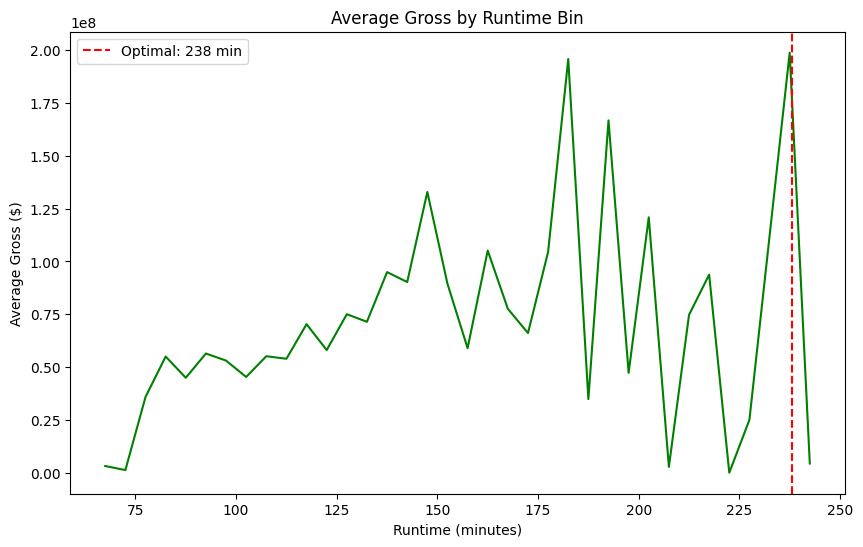


BLOCKBUSTER RUNTIME ANALYSIS
Optimal runtime window      : (235, 240]
Average gross in this bin   : $198,676,459
Recommended single runtime  : 238 minutes


In [72]:
# ==================================================
# RUNTIME ANALYSIS - VERSUS GROSS 2 DIFFERENT PLOTS
# ==================================================

# Filter out missing or zero data
df_runtime = df[(df["Runtime"].notna()) & (df["Gross"] > 0)].copy()

# Bin runtimes (5-minute intervals)
bins = range(int(df_runtime["Runtime"].min()), int(df_runtime["Runtime"].max()) + 5, 5)
df_runtime["Runtime_bin"] = pd.cut(df_runtime["Runtime"], bins=bins)

# Average gross per bin
bin_avg_gross = df_runtime.groupby("Runtime_bin")["Gross"].mean()

# Find the bin with the highest average gross
best_bin = bin_avg_gross.idxmax()
best_bin_avg_gross = bin_avg_gross.max()

# Calculate the mean runtime in that bin
optimal_runtime = df_runtime[df_runtime["Runtime_bin"] == best_bin]["Runtime"].mean()
# Create line plot with average line
plt.figure(figsize=(10,6))
sns.lineplot(x=[b.mid for b in bin_avg_gross.index], y=bin_avg_gross.values, color='green')
plt.axvline(optimal_runtime, color='red', linestyle='--', label=f'Optimal: {optimal_runtime:.0f} min')
# Add titles and labels for clarity
plt.title("Average Gross by Runtime Bin")
plt.xlabel("Runtime (minutes)")
plt.ylabel("Average Gross ($)")
plt.legend()
plt.show()
# Display output/info gathered
print("\n" + "="*70)
print("BLOCKBUSTER RUNTIME ANALYSIS")
print("="*70)
print(f"Optimal runtime window      : {best_bin}")
print(f"Average gross in this bin   : ${best_bin_avg_gross:,.0f}")
print(f"Recommended single runtime  : {optimal_runtime:.0f} minutes")
print("="*70)


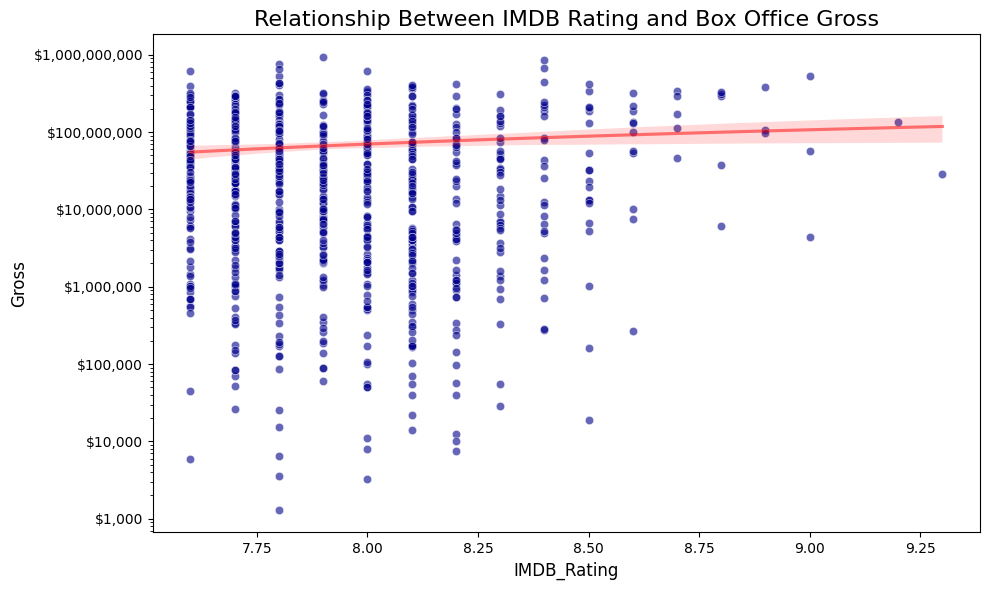

In [ ]:
# ==================================================
# IMDB RATING ANALYSIS - PLOT CREATION
# ==================================================

plt.figure(figsize=(10, 6))

# Create the scatter plot
sns.scatterplot(x="IMDB_Rating", y="Gross", data=df, alpha=0.6, color='darkblue')

# Apply the Logarithmic Scale
plt.yscale('log')

# Format ticks as money
ax = plt.gca()
ax.yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda y, _: '${:,.0f}'.format(y))
)

# Add titles and labels for clarity
plt.title('Relationship Between IMDB Rating and Box Office Gross', fontsize=16)
plt.xlabel('IMDB Rating (1-10)', fontsize=12)
plt.ylabel('Box Office Gross (Log Scale)', fontsize=12)

# Add a trend line for linear regression
sns.regplot(x="IMDB_Rating", y="Gross", data=df, scatter=False, color='red', line_kws={'alpha':0.5})
# Improve spacing
plt.tight_layout()
plt.show()


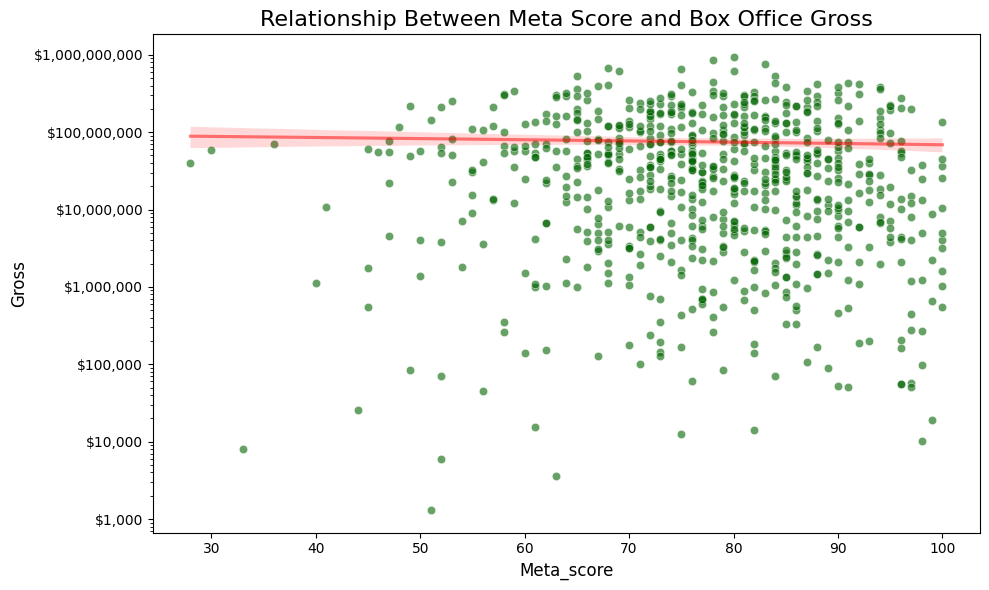

In [ ]:
# ==================================================
# META SCORE ANALYSIS - PLOT CREATION
# ==================================================

plt.figure(figsize=(10, 6))

# Create the scatter plot
sns.scatterplot(x="Meta_score", y="Gross", data=df, alpha=0.6, color='darkgreen')

# Apply the Logarithmic Scale
plt.yscale("log")

# Format ticks as money
ax = plt.gca()
ax.yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda y, _: '${:,.0f}'.format(y))
)

# Add titles and labels for clarity
plt.title('Relationship Between Meta Score and Box Office Gross', fontsize=16)
plt.xlabel('Meta Score (1-100)', fontsize=12)
plt.ylabel('Box Office Gross (Log Scale)', fontsize=12)

# Add a trend line for linear regression
sns.regplot(x="Meta_score", y="Gross", data=df, scatter=False, color='red', line_kws={'alpha':0.5})
# Improve spacing
plt.tight_layout()
plt.show()

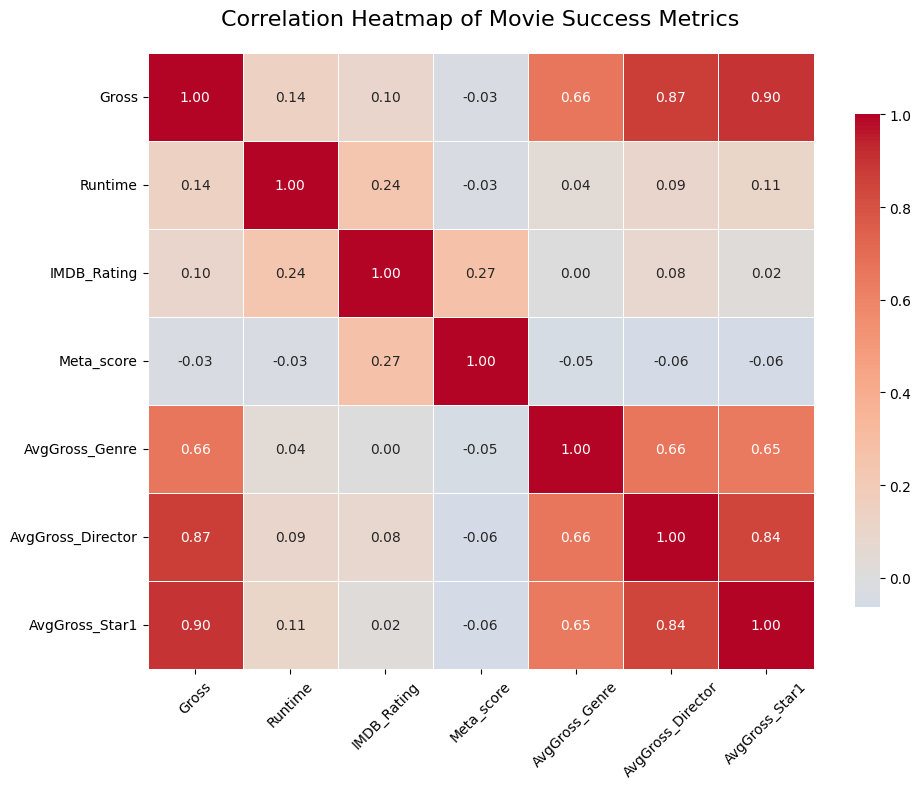

In [ ]:
# =======================================
# CORRELATION ANALYSIS — PLOT CREATION
# =======================================

# Compute mean gross by Genre, Director, and Star1
genre_avg = df.groupby("Genre")["Gross"].mean().rename("AvgGross_Genre")
director_avg = df.groupby("Director")["Gross"].mean().rename("AvgGross_Director")
star1_avg = df.groupby("Star1")["Gross"].mean().rename("AvgGross_Star1")

# Map the averages back to the main DataFrame
df["AvgGross_Genre"] = df["Genre"].map(genre_avg)
df["AvgGross_Director"] = df["Director"].map(director_avg)
df["AvgGross_Star1"] = df["Star1"].map(star1_avg)

# Create the columns for the eat map
heatmap_cols = ["Gross", "Runtime", "IMDB_Rating", "Meta_score",
                "AvgGross_Genre", "AvgGross_Director", "AvgGross_Star1"]
# Fnud the correlation of the columns in the heat map
heatmap_data = df[heatmap_cols].corr()


plt.figure(figsize=(10,8))
# Create the heat plot 
sns.heatmap(
    heatmap_data,
    annot=True,                # show correlation values
    fmt=".2f",
    cmap="coolwarm",            
    center=0,                  # center diverging palette at 0
    linewidths=0.5,            # subtle cell borders
    cbar_kws={"shrink": 0.8}  # smaller color bar
)
# Add titles and labels for clarity
plt.title("Correlation Heatmap of Movie Success Metrics", fontsize=16, pad=20)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
# Improve spacing
plt.tight_layout()
plt.show()


In [49]:
# ======================================================
# BLOCKBUSTER BLUEPRINT — DISPLAYING ALL FINAL DATA
# ======================================================

# Calculate budget recommendation
predicted_gross = best_pair[2]  # your predicted gross from the top star pairing
recommended_budget = predicted_gross / 3  # typical blockbuster ROI rule

# Print the blockbuster blueprint
print("\n\n==================== BLOCKBUSTER BLUEPRINT ====================\n")
print(f"Most profitable genre: {top_genre}")
print(f"Optimal runtime: {best_bin} mintues")
print(f"Top star pairing: {best_pair[0]} + {best_pair[1]}")
print(f"Top director (ROI): {top_director}")
print("Recommended meta score range: 60+ (based on scatter trends)")
print("Recommended IMDB rating target: 7.5-8.5 (based on scatter trends)")
print(f"Predicted gross (pairing-based estimate): ${predicted_gross:,.0f}")
print(f"Budget recommendation: ${recommended_budget:,.0f} (Gross / 3 rule)")
print("\n===============================================================")





==================== BLOCKBUSTER BLUEPRINT ====================

Most profitable genre: Adventure
Optimal runtime: (235, 240] mintues
Top star pairing: Daniel Radcliffe + Leonardo DiCaprio
Top director (ROI): Steven Spielberg
Recommended meta score range: 60+ (based on scatter trends)
Recommended IMDB rating target: 7.5-8.5 (based on scatter trends)
Predicted gross (pairing-based estimate): $305,983,506
Budget recommendation: $101,994,502 (Gross / 3 rule)



C:\Users\Amelia Eric-Markovic\AppData\Local\Temp\ipykernel_5504\3590019690.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  predicted_gross = best_pair[2]  # your predicted gross from the top star pairing
C:\Users\Amelia Eric-Markovic\AppData\Local\Temp\ipykernel_5504\3590019690.py:13: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"Top star pairing: {best_pair[0]} + {best_pair[1]}")



## Discussion

### Final Analysis of Blockbuster Movie Data

**1. Genre Analysis**

Based on a genre analysis of box office performance, films categorized as **Family + Sci-Fi** and **Action + Adventure + Fantasy** are the top earners, averaging over $\$350$ million in gross revenue. In terms of total and average gross earnings, each of the three genres **Adventure, Sci-Fi, and Action** dominates, with Adventure films topping the list with an average of $\$165$ million per release. According to this data, some genres are strong and reliable sources of high box office revenue, particularly those that are adventure-oriented or have high-concept family or fantasy themes. For major blockbuster projects, studios should strategically prioritize these popular, high-grossing categories because genre choice is a critical predictor of financial success. In order to give the director creative freedom to add other genres while still achieving financial success, we will ultimately choose adventure as the only genre to pitch. 

**2. Director Analysis**

Choosing the right director is a crucial factor, which through our heat map correlation of $\$0.87$ between director choice and gross, has been strongly linked to a film's box office success. Even though **Anthony Russo** is currently has the highest average overall gross per film, earning $\$551$ million per film, consistency and critical reception shows a different trend. With at least five films under his belt and an average IMDB score of $\$8.46$ and an average gross of $\$242$ million over his eight films, **Christopher Nolan** displays a strong dependability. This demonstrates that both established reputation and prior performance are important indicators. Directors with fewer, highly profitable films can achieve a higher average gross, but stable studio planning is highly valued for long-term consistency and critical acclaim, such as Nolan's.

**3. Cast / Lead Actor Analysis**

Casting decisions, especially the leading actors, are just as crucial in determining a movie's potential to be a blockbuster as the director's influence. With a combined historical gross of $\$1.7$ billion, analysis reveals that **Daisy Ridley and Sam Worthington** are the most promising pairing that have never starred in a movie side by side. With a combined power of $\$514$ million, the highest-grossing pair of actors with established careers (more than five films) is **Daniel Radcliffe and Leonardo DiCaprio**. This shows that carefully matching high-appeal talent can greatly increase potential revenue.  This influence is highlighted by the strong correlation (0.90) between the choice of lead actor and box office receipts, indicating that choosing actors with a track record of multiple successful films is a highly successful approach for projects aiming for predictable financial success.

**4. Runtime Analysis**

A limited window of **235 to 240 minutes** seems to be the ideal runtime for high-grossing movies, indicating a "sweet spot" for blockbusters.  The average gross for films in this particular range is $\$198$ million, and a successful blockbuster should be **roughly 238 minutes** in length. This particular finding implies that for epic films, this duration is ideal for striking a balance between thorough storytelling depth and sustained audience engagement, despite the weak overall correlation between longer runtimes and higher total gross.

**5. Critial Ratings**

<ins>Relationship Between Meta Score and Box Office Gross Scatter Plot Analysis</ins>

The scatter plot shows the Meta_score (on the x-axis, ranging from $\approx 30$ to $100$) plotted against the Gross (on the y-axis, shown on a logarithmic scale, ranging from $\approx \$1,000$ to $\$1,000,000,000$).The most important finding is the existence of an almost perfectly horizontal regression line (the red line with the shaded pink confidence interval).  This horizontal line shows that the Meta_score and the Box Office Gross have little to no linear correlation. To put it another way, raising the Meta_score does not consistently indicate a significantly higher Box Office Gross. Most high-grossing films (those above the $\$10,000,000$ mark on the y-axis) are dispersed throughout the whole Meta_score range from $\approx 50$ to $100$. In general, the lowest grossing films (below $\$1,000,000$ on the y-axis) seem to be grouped at the lower end of the Meta_score range (below $\approx 60$). However, even in this lower score range, there are still movies that gross over $\$10,000,000$.
**Aim for a Score of 60 or Higher**: To avoid the cluster of very low-grossing films that tend to have scores under **60**, the director should aim to achieve a Meta_score of 60 or better.

<ins>Relationship Between IMDB Rating and Box Office Gross Scatter Plot Analysis</ins>

The scatter plot displays the Gross (on the y-axis, displayed on a logarithmic scale, ranging from $\approx~1,000$ to $\$1,000,000,000$) against the IMDb Rating (on the x-axis, ranging from $\approx 3.0$ to $9.0$). The red line with the pink confidence interval, which represents the regression line, is extremely nearly horizontal.  This suggests that there is little to no useful relationship between the audience-driven IMDb score and the movie's box office gross across the whole range of IMDb scores. The **7.5 to 8.5** range seems to have the densest concentration of high-grossing movies.  Blockbuster films—those with the largest budgets and marketing campaigns—often fall into this score range.  A score in this range should satisfy the director.
**Aim for a Score of 7.5-8.5 or Higher**: To avoid the cluster of very low-grossing films that tend to have scores under $60$, the director should aim to achieve a Meta_score of 60 or better.

<ins>Overview</ins>

Higher financial gross is least likely correlated with positive critical ratings, or **IMDB scores between 7.5 and 8.5** and **Meta Scores of 60** or higher; regression analysis reveals almost flat trends. This shows that high critical ratings by themselves do not guarantee box office success. The key takeaway is that, although critical acclaim is useful, it is in the end not what determines a film's financial success but rather, elements like star power, audience appeal, and effective marketing typically have a far greater influence. Filmmakers should therefore strive for a strong, attainable critical reception within the 7.5–8.5 IMDB and $\approx 60$ Meta range rather than prioritizing ratings at the expense of other crucial commercial considerations, mainly to avoid producing exceptionally low-performing films.

**6. Correlation Heatmap**

A number of important movie metrics, such as Gross, Runtime, IMDB_Rating, Meta_score, and average gross values for Genre, Director, and Star1 (Lead Actor), are correlated in the heatmap.  The findings show that the **strongest positive correlations are between Gross and the average gross for Director (0.87) and Star1 (0.90)**, indicating that some directors and lead actors are consistently responsible for better box office results.  There is a fairly strong correlation (0.66) between average gross by genre and overall gross, indicating that genre choice is a significant predictor of financial success. **Runtime, IMDB_Rating, Meta_score, and gross** have much weaker correlations, all of which are close to zero.This demonstrates that longer or critically acclaimed films don't always earn more money. Overall, the heatmap shows that the past performance of those involved in a film and its genre is a better gauge of commercial success than traditional quality metrics or runtime. This lends credence to the idea that blockbuster success is often influenced by popular genres and well-known performers rather than just critical acclaim.

**7. Overview: Final Insights**

Blockbuster success focused less on achieving high critical acclaim or a specific film length and more on a strategic combination of proven talent and genre selection. The best formula for generating high revenue is pairing high-grossing lead actors with successful directors in currently popular genres. While factors like an ideal runtime (around 238 minutes), an IMDB rating between 7.5 and 8.5, and a Meta Score above 60 offer some guidance, they are not the primary indicator of financial success. In conclusion, the data definitively shows that familiar talent and blockbuster-friendly genres are the key factors driving financial outcomes, with critical ratings and runtime having limited predictive power. Therefore, studios should prioritize leveraging historical box office directors, making strategic casting decisions, and following genre trends to maximize success, rather than focusing on chasing purely high ratings or extreme runtimes.


**Limitations & next steps:** The dataset is limited to top 1000 titles and may have biases (selection bias toward popular or critically acclaimed titles). For more rigorous analysis one could:
- Acquire a larger, more representative sample of IMDB titles.
- Use time-based trend analysis with more granular time series methods.
- If modelling, try a simple linear regression predicting Rating using Votes and Year (within constraints), or run a k-means clustering (k ≤ 4) on features like Rating, Votes, and Year to find natural groupings.




## References
*No GenAI Disclosure - No AI used in this project*

- Shankhdhar, H. (2021, February 1). IMDB movies dataset. Kaggle. https://www.kaggle.com/datasets/harshitshankhdhar/imdb-dataset-of-top-1000-movies-and-tv-shows 
- Python packages used: `pandas`, `numpy`, `matplotlib`.

**Course Materials**

- CSCI2000U Scientific Data Analysis. Course lectures, assignment instructions, and tutorial materials. Ontario Tech University, Canada.

**Research**
- Matplotlib - tick formatters. Tutorialspoint. (n.d.). https://www.tutorialspoint.com/matplotlib/matplotlib_tick_formatters.htm 
- How to use Groupby and Aggregate for exploratory data analysis in pandas ?. How to use Groupby and aggregate operations for exploratory data analysis with pandas ? (Jupyter notebook). (n.d.). https://en.moonbooks.org/Jupyter/introduction_to_groupby_with_pandas/ 
- Cite your Sources Today. Citation Machine. (n.d.). https://www.citationmachine.net/
